In [3]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go



In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import plotly.io as pio


In [6]:
# 1. Load the dataset 
df = pd.read_csv('Africa_climate_change.csv')

In [7]:
print("Missing Value:")
print(df.isnull().mean()*100)

Missing Value:
DATE        0.000000
PRCP       61.796629
TAVG        1.371729
TMAX       21.710573
TMIN       28.410873
COUNTRY     0.000000
dtype: float64


## Data Cleaning

### Missing Values
* **No Action Required:** The `DATE`, `PRCP`, `COUNTRY`, and `Year` columns contain 0% null values.
* **Mean Imputation:** Missing values in `PRCP` (61.0%), `TAVG` (1.4%), `TMAX` (21.7%), and `TMIN` (28.4%)—will be filled using each column's respective mean value.

### Outliers
* **Detection Method:** The Interquartile Range (IQR) method will be used to identify anomalies.
* **Target Columns:** Outlier screening will be applied to all numerical features (`TAVG`, `PRCP`, `TMAX`, and `TMIN`).


### Handling missing values

In [8]:
def impute_mean(series):
    mean_value=series.mean()
    series=series.fillna(mean_value)
    return series

In [14]:
df['TAVG']=impute_mean(df['TAVG'])
df['TMAX']=impute_mean(df['TMAX'])
df['TMIN']=impute_mean(df['TMIN'])
df['PRCP']=impute_mean(df['PRCP'])

In [15]:
print("Missing values:")
print(df.isnull().mean()*100)

Missing values:
DATE       0.0
PRCP       0.0
TAVG       0.0
TMAX       0.0
TMIN       0.0
COUNTRY    0.0
dtype: float64


In [ ]:
df.info()

### Handling Outliers

In [16]:
def filter_outliers(df,column_list):
    for c in column_list:
        Q1 =df[c].quantile(0.25)
        Q3 =df[c].quantile(0.75)
        IQR =Q3-Q1
        lower_limit = Q1 -(1.5*IQR)
        higher_limit = Q3 + (1.5*IQR)
        df = df[df[c].between(lower_limit,higher_limit)]
        return df       


In [17]:
column_list=['TAVG','PRCP','TMIN','TMAX']
df=filter_outliers(df,column_list)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 462315 entries, 0 to 464814
Data columns (total 6 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   DATE     462315 non-null  object 
 1   PRCP     462315 non-null  float64
 2   TAVG     462315 non-null  float64
 3   TMAX     462315 non-null  float64
 4   TMIN     462315 non-null  float64
 5   COUNTRY  462315 non-null  object 
dtypes: float64(4), object(2)
memory usage: 24.7+ MB


### Data Cleaning Results
After the data cleaning process, we were able to remove outliers and impute all missing values.
As a result, the data set was retained.
99.46% of the rows were retained, and there are no missing values.



### Conversion of Date Type

The DATE column is converted from text format to a datetime type so that date-based operations can be performed correctly. The year is then extracted from each date and stored in a new Year column. The dataset is filtered to include only Tunisia and Cameroon, after which the average annual temperature (TAVG) is calculated for each country. This prepares the data for time-series analysis and visualization of temperature trends over time.

In [19]:
df['DATE'] = pd.to_datetime(df['DATE'])


In [20]:
df['Year'] = df['DATE'].dt.year

In [21]:
# Check your columns to see if it loaded properly
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 462315 entries, 0 to 464814
Data columns (total 7 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   DATE     462315 non-null  datetime64[ns]
 1   PRCP     462315 non-null  float64       
 2   TAVG     462315 non-null  float64       
 3   TMAX     462315 non-null  float64       
 4   TMIN     462315 non-null  float64       
 5   COUNTRY  462315 non-null  object        
 6   Year     462315 non-null  int32         
dtypes: datetime64[ns](1), float64(4), int32(1), object(1)
memory usage: 26.5+ MB
None


,DATE,PRCP,TAVG,TMAX,TMIN,COUNTRY,Year
0,1980-01-01,0.0,54.0,61.0,43.000000,Tunisia,1980
1,1980-01-01,0.0,49.0,55.0,41.000000,Tunisia,1980
2,1980-01-01,0.0,72.0,86.0,59.000000,Cameroon,1980
3,1980-01-01,0.0,50.0,55.0,43.000000,Tunisia,1980
4,1980-01-01,0.0,75.0,91.0,65.548262,Cameroon,1980


In [22]:
df_line = df[df['COUNTRY'].isin(['Tunisia', 'Cameroon'])]
df_annual_avg = df_line.groupby(['Year', 'COUNTRY'])['TAVG'].mean().reset_index()


### Plotting a Line Chart

This visualization creates a line chart to show how average temperatures have changed from 1980 to 2023. Each country is represented by its own line, making it easy to compare temperature trends between countries over time. The horizontal axis shows the year, while the vertical axis shows the average temperature in degrees Celsius. The chart helps identify whether temperatures have generally increased, decreased, or remained stable throughout the period.


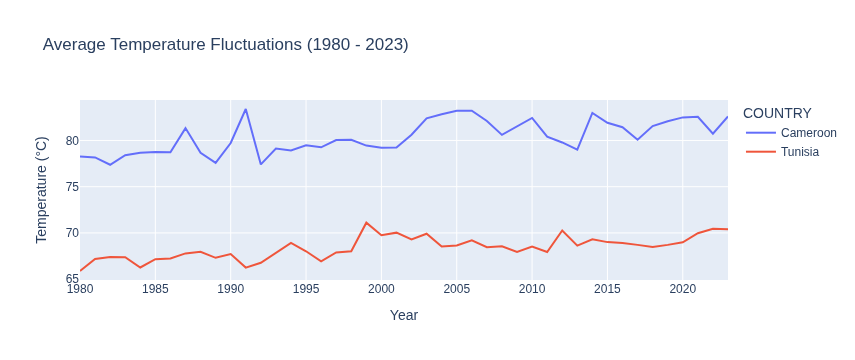

In [23]:
fig1 = px.line(
    df_annual_avg, 
    x='Year', 
    y='TAVG', 
    color='COUNTRY',
    title='Average Temperature Fluctuations (1980 - 2023)',
    labels={'TAVG': 'Temperature (°C)', 'Year': 'Year'}
)
fig1.show()

In [26]:
df_zoomed = df_annual_avg[(df_annual_avg['Year'] >= 1980) & (df_annual_avg['Year'] <= 2005)]

In [27]:
fig2 = px.line(
    df_zoomed, 
    x='Year', 
    y='TAVG', 
    color='COUNTRY',
    title='Zoomed In: Temperature Trends (1980 - 2005)',
    labels={'TAVG': 'Observed Mean Temperature (°C)', 'Year': 'Timeline (Years)'}
)


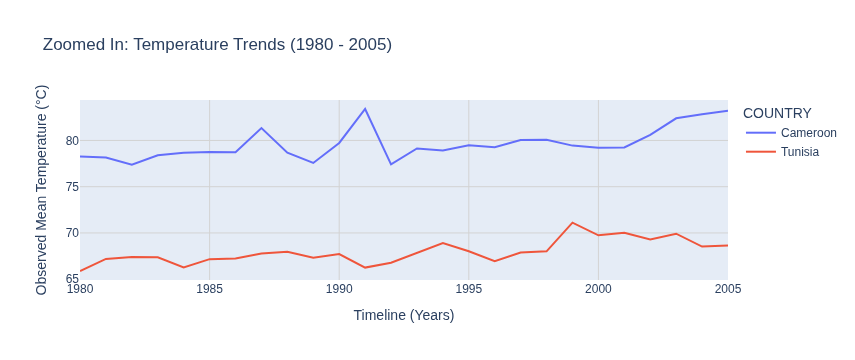

In [28]:
fig2.update_xaxes(dtick=5, gridcolor='LightGray')
fig2.update_yaxes(gridcolor='LightGray')

fig2.show()

### Senegal Analysis

This analysis compares the distribution of average temperatures in Senegal across two periods: 1980–2000 and 2001–2023. Separate histograms are plotted for each era to visualize how temperatures are distributed and to identify any shifts over time. The mean and median temperatures for both periods are also displayed on the chart to help assess the shape and skewness of the distributions. When the mean and median are very close, the distribution is likely close to normal (symmetrical), while larger differences may indicate skewness. This visualization makes it easier to compare temperature patterns between the two eras and observe any changes in Senegal's climate over time.

In [29]:
df_senegal = df[df['COUNTRY'] == 'Senegal']

In [30]:
year_1980_2000 = df_senegal[(df_senegal['Year'] >= 1980) & (df_senegal['Year'] <= 2000)]
year_2001_2023 = df_senegal[(df_senegal['Year'] > 2000) & (df_senegal['Year'] <= 2023)]

In [32]:
mean_old = year_1980_2000['TAVG'].mean()
mean_new = year_2001_2023['TAVG'].mean()

In [33]:
plt.figure(figsize=(10, 6))


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [35]:
sns.set_theme(style="whitegrid") # Adds a grid

In [37]:
median_old = year_1980_2000['TAVG'].median()
median_new = year_2001_2023['TAVG'].median()

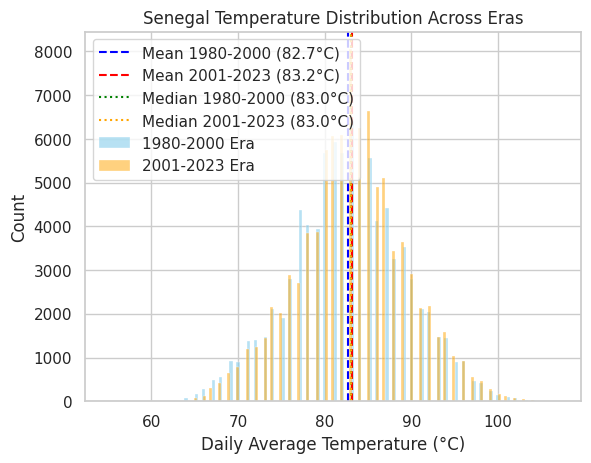

In [40]:
sns.histplot(year_1980_2000['TAVG'], color="skyblue", label="1980-2000 Era", alpha=0.6)
sns.histplot(year_2001_2023['TAVG'], color="orange", label="2001-2023 Era", alpha=0.5)
plt.axvline(mean_old, linestyle="--", label=f"Mean 1980-2000 ({mean_old:.1f}°C)", color="blue")
plt.axvline(mean_new, linestyle="--", label=f"Mean 2001-2023 ({mean_new:.1f}°C)", color="red")
plt.axvline(median_old, linestyle=":", label=f"Median 1980-2000 ({median_old:.1f}°C)", color="green")
plt.axvline(median_new, linestyle=":", label=f"Median 2001-2023 ({median_new:.1f}°C)", color="orange")
plt.title("Senegal Temperature Distribution Across Eras")
plt.xlabel("Daily Average Temperature (°C)")
plt.ylabel("Count")
plt.legend()

### Average Temperature Analysis

This visualization calculates and compares the average temperature for each country across the period 1980–2023. A bar chart is used to display the results, with each bar representing a country's overall average temperature. The countries are sorted from highest to lowest average temperature to make comparisons easier. Temperature values are also displayed above each bar, allowing viewers to quickly identify and compare the averages. This chart provides a clear summary of how average temperatures differ between the selected African countries over the study period.

#### Why a bar chart?

A bar chart is appropriate because the goal is to compare a single numerical value (average temperature) across several categories (countries). The differences between countries can be easily seen by comparing the heights of the bars. Unlike line charts, which are best for showing trends over time, bar charts are designed for comparing categories, making them the most straightforward and interpretable choice for this analysis.

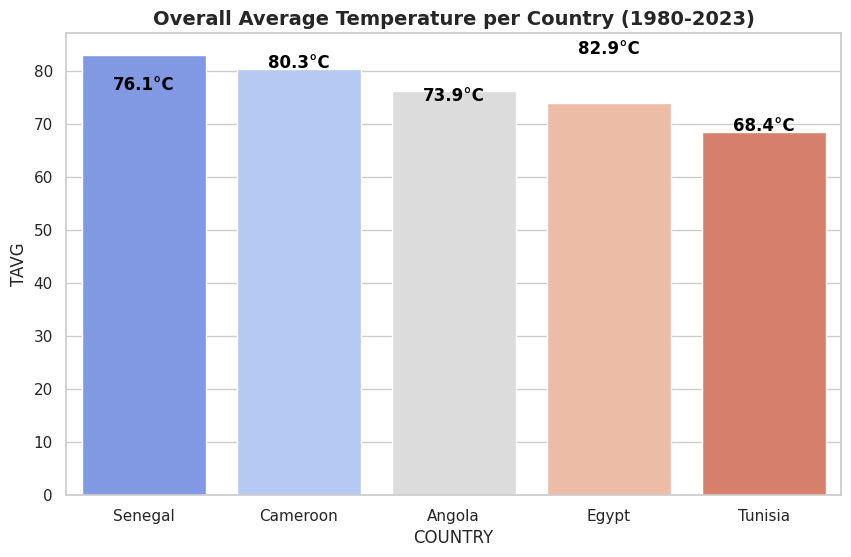

In [41]:
df_country_avg = df.groupby('COUNTRY')['TAVG'].mean().reset_index()
df_country_avg = df_country_avg.sort_values(by='TAVG', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=df_country_avg, x='COUNTRY', y='TAVG', hue='COUNTRY', palette='coolwarm', legend=False)
for index, row in df_country_avg.iterrows():
    plt.text(index, row['TAVG'] + 0.3, f"{row['TAVG']:.1f}°C", color='black', ha="center", fontweight='bold')
    plt.title("Overall Average Temperature per Country (1980-2023)", fontsize=14, fontweight='bold')
    plt.title("Overall Average Temperature per Country (1980-2023)", fontsize=14, fontweight='bold')


plt.show()

In [ ]:
print(df.info())
df.head()